# VocEd Lab 03-v2 — Targeted Artifact Removal

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/emilsar/VocEd/blob/main/03v2_stain_deconvolution.ipynb)

Lab 03 added generic morphological operations (opening, closing) to the Lab 02 grayscale
threshold.  The improvement was marginal.  Why?  Opening and closing smooth boundaries and
remove tiny objects *everywhere* — but the real failure mode is more specific: small spurious
blobs of nucleus-labelled pixels (cell debris, staining blemishes, noise) scattered inside the
cytoplasm region.  Because they are *dark enough* to fall below the nucleus threshold, the
grayscale pipeline labels them as nucleus — inflating the N/C ratio.  Generic morphology cannot
distinguish these blemishes from real nucleus pixels.

This lab takes a more targeted approach based on a simple biological fact:

> **Real nuclei are large.**  Any nucleus-labelled region that is too small to be a real
> nucleus is almost certainly an artefact — debris or a staining blemish.

**New pipeline:**  
`grayscale threshold → drop small nucleus blobs → fill nucleus holes → drop small cytoplasm blobs`

By the end of this lab you will be able to:
- Visualise and quantify spurious nucleus blobs in the predicted nucleus mask.
- Implement a size filter using connected-component labelling.
- Tune the pipeline with Bayesian optimisation and compare it to Labs 01 and 02.
- Compute N/C ratio predictions and R² vs the identity line.


## 0. Setup

In [1]:
!pip install scikit-optimize scikit-image --quiet

# Clone the repo (skip if already present)
!git clone https://github.com/emilsar/VocEd.git 2>/dev/null || echo 'Already cloned.'
%cd VocEd

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 2.3 MB/s eta 0:00:00
/content/VocEd


## 1. Load Data & Recreate the Train/Test Split

In [2]:
import glob
import numpy as np
import matplotlib.pyplot as plt
import skimage.filters as skf
import skimage.morphology as skm
import skimage.restoration as skr
from skimage.measure import label          # connected-component labelling
from scipy.ndimage import binary_fill_holes
from skopt import gp_minimize
from skopt.space import Real

N = len(glob.glob('imagedata/X/*.npy'))
X = np.stack([np.load(f'imagedata/X/{i}.npy') for i in range(N)])
y = np.stack([np.load(f'imagedata/y/{i}.npy') for i in range(N)])

np.random.seed(42)
idx       = np.random.permutation(N)
train_idx = idx[:160]
test_idx  = idx[160:]

def to_gray(img):
    """Standard ITU-R grayscale from a (3, H, W) float32 image."""
    return 0.299 * img[0] + 0.587 * img[1] + 0.114 * img[2]

def segment_gray(img, t_nuc, t_bg):
    """Lab 01/02 grayscale threshold pipeline â€” kept here for comparison."""
    gray = to_gray(img)
    pred = np.zeros(gray.shape, dtype=np.int64)
    pred[gray < t_nuc]                    = 2
    pred[(gray >= t_nuc) & (gray < t_bg)] = 1
    return pred

def dice_score(pred, target, cls):
    p = pred   == cls
    t = target == cls
    inter = (p & t).sum()
    denom = p.sum() + t.sum()
    return 1.0 if denom == 0 else 2 * inter / denom

print(f'Loaded {N} images.  Train: {len(train_idx)}  Test: {len(test_idx)}')


Loaded 200 images.  Train: 160  Test: 40


## 2. What Artefacts Look Like

Before fixing the problem, let's see it.  We run the Lab 02 grayscale threshold on image 7
and then label every connected component in the predicted nucleus mask.

A **connected component** is a set of pixels that are all touching each other.  A real nucleus
should form one large, roughly circular region.  Tiny specks of nucleus-labelled pixels
scattered across the cytoplasm are almost certainly artefacts — cell debris, staining
blemishes, or noise that happens to fall below the nucleus threshold.

We identify these artefacts by **size**: any nucleus connected component smaller than a fixed
pixel threshold is flagged as spurious and removed.


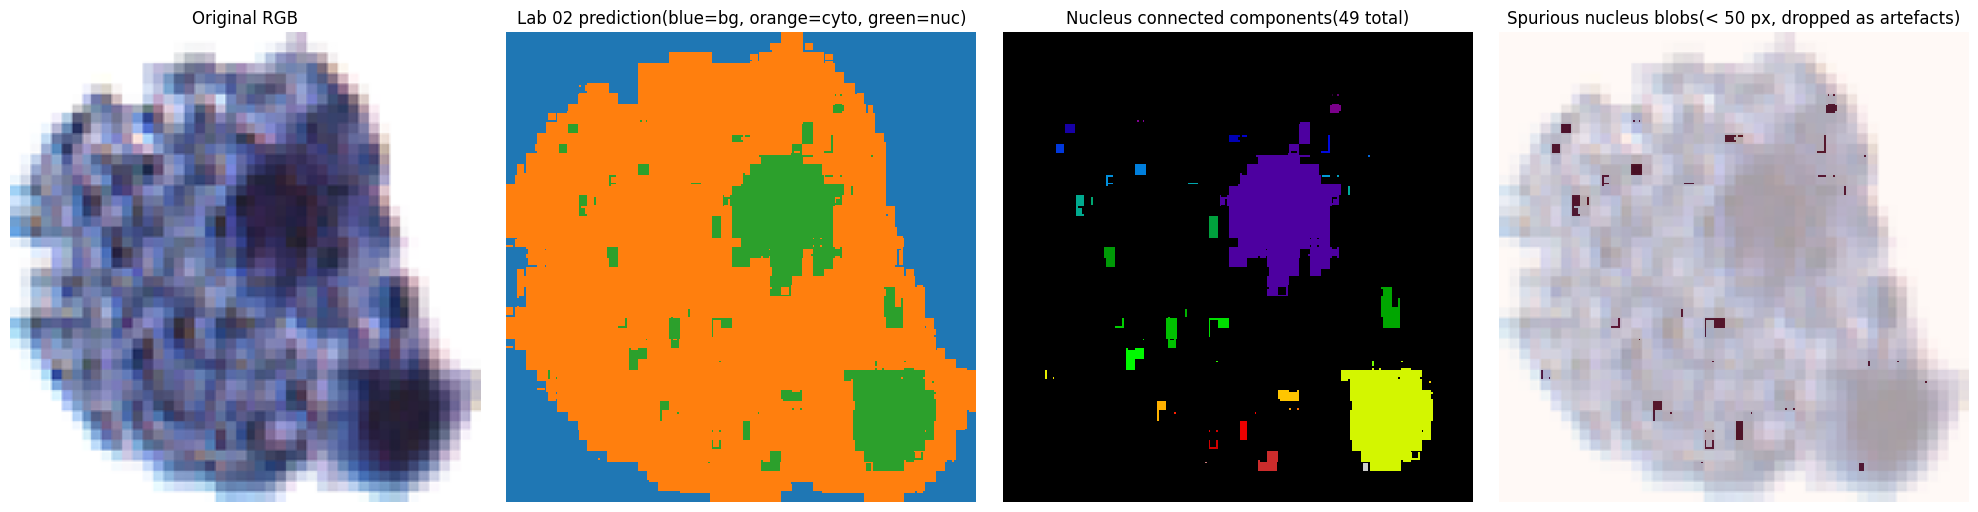

Nucleus connected components: 49
Spurious blobs (< 50 px): 40
Artefact pixels: 394
Total nucleus pixels: 6,478
Artefact fraction: 6.1%


In [6]:
IDX = 7
pred02_7  = segment_gray(X[IDX], 0.25, 0.95)
nuc7      = pred02_7 == 2

# Label every connected component in the nucleus mask
nuc_cc    = label(nuc7)                            # integer map: each blob gets a unique id
n_cc      = nuc_cc.max()

# Blobs smaller than min_size pixels are almost certainly not real nuclei
min_size  = 50
sizes     = np.bincount(nuc_cc.ravel())            # sizes[i] = pixel count of blob i
small_ids = np.where(sizes < min_size)[0]          # ids of blobs that are too small
small_ids = small_ids[small_ids > 0]               # exclude background (id = 0)
artifacts = np.isin(nuc_cc, small_ids)             # boolean mask of spurious nucleus pixels

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(X[IDX].transpose(1, 2, 0))
axes[0].set_title('Original RGB')

axes[1].imshow(pred02_7, cmap='tab10', vmin=0, vmax=9, interpolation='nearest')
axes[1].set_title('Lab 02 prediction(blue=bg, orange=cyto, green=nuc)')

axes[2].imshow(nuc_cc, cmap='nipy_spectral', interpolation='nearest')
axes[2].set_title(f'Nucleus connected components({n_cc} total)')

axes[3].imshow(X[IDX].transpose(1, 2, 0))
axes[3].imshow(artifacts, cmap='Reds', alpha=0.6, interpolation='nearest')
axes[3].set_title(f'Spurious nucleus blobs(< {min_size} px, dropped as artefacts)')

for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

print(f'Nucleus connected components: {n_cc}')
print(f'Spurious blobs (< {min_size} px): {len(small_ids)}')
print(f'Artefact pixels: {artifacts.sum():,}')
print(f'Total nucleus pixels: {nuc7.sum():,}')
print(f'Artefact fraction: {artifacts.sum() / max(nuc7.sum(), 1):.1%}')


## 3. The Targeted Cleanup Pipeline

The new pipeline has three stages:

1. **Grayscale threshold** â€” identical to Lab 02.
2. **Nucleus cleanup** â€” two operations aimed at the specific failure modes of grayscale thresholding on nuclei:
   - `remove_small_objects` â€” drops tiny dark specks (debris, artefacts) that fall below the nucleus threshold but are too small to be a real nucleus.
   - `binary_fill_holes` â€” plugs lighter holes *inside* a nucleus region caused by uneven staining across the nucleus body.  These holes would otherwise be mislabelled as cytoplasm.
3. **Cytoplasm cleanup** â€” `remove_small_objects` removes isolated small blobs in the cytoplasm mask (cell debris, staining artefacts) that are too small to be real cytoplasm.

**Parameters for Bayesian optimisation:**

| Parameter | Meaning | Search range |
|---|---|---|
| `t_nuc` | Nucleus grayscale threshold | [0.10, 0.70] |
| `t_bg` | Background grayscale threshold | [0.50, 0.99] |
| `min_nuc_size` | Min nucleus fragment size (pixels) | [10, 500] |
| `min_cyto_size` | Min cytoplasm fragment size (pixels) | [10, 500] |

In [18]:
def segment_morph(img, t_nuc, t_bg, min_nuc_size=20, min_cyto_size=20,
                  blur_sigma=1.5):
    """
    Targeted cleanup pipeline with Gaussian blur â†’ NLM preprocessing.

    img           : (3, H, W) float32, channels-first
    t_nuc         : grayscale threshold for nucleus (darker pixels â†’ nucleus)
    t_bg          : grayscale threshold for background (brighter pixels â†’ background)
    min_nuc_size  : nucleus fragments smaller than this (pixels) are removed
    min_cyto_size : cytoplasm fragments smaller than this (pixels) are removed
    blur_sigma    : sigma for Gaussian blur (applied before NLM)
    """
    img_hwc = img.transpose(1, 2, 0)   # (H, W, C) for skimage

    #Pre-processing: Gaussian blur
    img_hwc = skf.gaussian(img_hwc, sigma=blur_sigma, channel_axis=-1)
    sig     = np.mean(skr.estimate_sigma(img_hwc, channel_axis=-1))
    img_hwc = skr.denoise_nl_means(img_hwc, h=3 * sig,
                                   patch_size=5, patch_distance=6,
                                   fast_mode=True, channel_axis=-1)

    #Stage 1: grayscale threshold
    gray = 0.299 * img_hwc[:, :, 0] + 0.587 * img_hwc[:, :, 1] + 0.114 * img_hwc[:, :, 2]
    nuc_mask  = gray < t_nuc
    bg_mask   = gray > t_bg
    cyto_mask = ~nuc_mask & ~bg_mask

    # Stage 2: nucleus cleanup
    nuc_mask = skm.remove_small_objects(nuc_mask, min_size=int(min_nuc_size))
    nuc_mask = binary_fill_holes(nuc_mask)   # fill lighter holes inside nuclei

    #Stage 3: cytoplasm cleanup
    if cyto_mask.any():
        cyto_mask = skm.remove_small_objects(cyto_mask, min_size=int(min_cyto_size))

    pred = np.zeros(gray.shape, dtype=np.int64)
    pred[cyto_mask] = 1
    pred[nuc_mask]  = 2
    return pred


pred_morph7 = segment_morph(X[7], 0.45, 0.85)
print('Classes present:', np.unique(pred_morph7))


Classes present: [0 1 2]


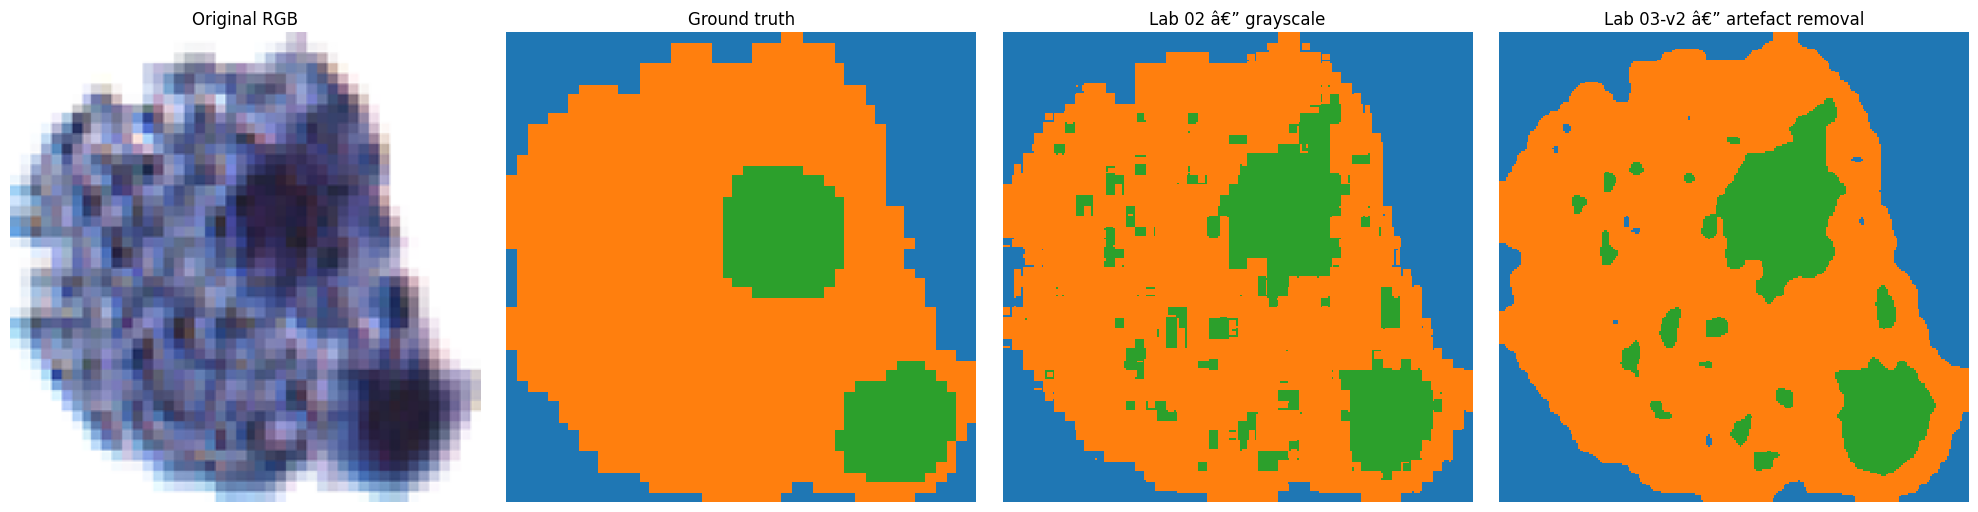

Image 7 â€” grayscale           cytoplasm=0.906  nucleus=0.669  mean=0.788
Image 7 â€” artefact removal    cytoplasm=0.922  nucleus=0.709  mean=0.816


In [19]:
## 4. Visual Comparison on Image 7

pred_gray7  = segment_gray( X[7], 0.29, 0.95)
pred_morph7 = segment_morph(X[7], 0.29, 0.95)   # same thresholds, artefact removal added

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(X[7].transpose(1, 2, 0));                                   axes[0].set_title('Original RGB')
axes[1].imshow(y[7],         cmap='tab10', vmin=0, vmax=9, interpolation='nearest'); axes[1].set_title('Ground truth')
axes[2].imshow(pred_gray7,   cmap='tab10', vmin=0, vmax=9, interpolation='nearest'); axes[2].set_title('Lab 02 â€” grayscale')
axes[3].imshow(pred_morph7,  cmap='tab10', vmin=0, vmax=9, interpolation='nearest'); axes[3].set_title('Lab 03-v2 â€” artefact removal')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

for name, pred in [('grayscale', pred_gray7), ('artefact removal', pred_morph7)]:
    d1 = dice_score(pred, y[7], 1)
    d2 = dice_score(pred, y[7], 2)
    print(f'Image 7 â€” {name:18s}  cytoplasm={d1:.3f}  nucleus={d2:.3f}  mean={0.5*(d1+d2):.3f}')

## 5. Bayesian Optimisation

We optimise all four parameters jointly.  The objective is the same as Labs 02 and 03:
maximise mean Dice over the 160 training images.

> **Note:** expect this cell to take **3â€“6 minutes**.

In [ ]:
def objective(params):
    t_nuc, t_bg, min_nuc_size, min_cyto_size = params
    scores = []
    for i in train_idx:
        pred = segment_morph(X[i], t_nuc, t_bg,
                             min_nuc_size=min_nuc_size,
                             min_cyto_size=min_cyto_size)
        scores.append((dice_score(pred, y[i], 1) + dice_score(pred, y[i], 2)) / 2)
    return -np.mean(scores)

search_space = [
    Real(0.10, 0.70, name='t_nuc'),
    Real(0.50, 0.99, name='t_bg'),
    Real(10,   500,  name='min_nuc_size'),
    Real(10,   500,  name='min_cyto_size'),
]

print('Running Bayesian optimisation (50 evals)â€¦')
result = gp_minimize(
    func=objective,
    dimensions=search_space,
    n_calls=50,
    n_initial_points=10,
    random_state=42,
    verbose=False,
)
print('Done.')

best_t_nuc, best_t_bg, best_min_nuc, best_min_cyto = result.x
print(f'Best params:  t_nuc={best_t_nuc:.4f}  t_bg={best_t_bg:.4f}  '
      f'min_nuc_size={best_min_nuc:.0f}  min_cyto_size={best_min_cyto:.0f}')
print(f'Train Dice:   {-result.fun:.4f}')

## 6. Test-Set Dice Comparison

In [ ]:
# â”€â”€ Re-run Lab 02 Bayesian optimisation for a fair grayscale baseline â”€â”€â”€â”€â”€â”€â”€â”€â”€
def objective_gray(params):
    t_nuc, t_bg = params
    scores = [(dice_score(segment_gray(X[i], t_nuc, t_bg), y[i], 1)
             + dice_score(segment_gray(X[i], t_nuc, t_bg), y[i], 2)) / 2
              for i in train_idx]
    return -np.mean(scores)

print('Re-running Lab 02 Bayesian optimisationâ€¦')
res02 = gp_minimize(objective_gray,
                    [Real(0.10, 0.70), Real(0.50, 0.99)],
                    n_calls=50, n_initial_points=10, random_state=42, verbose=False)
print('Done.')

# â”€â”€ Evaluate on the test set â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
def test_dice_mean(pred_fn):
    return np.mean([(dice_score(pred_fn(i), y[i], 1) + dice_score(pred_fn(i), y[i], 2)) / 2
                    for i in test_idx])

d_lab01   = test_dice_mean(lambda i: segment_gray( X[i], 0.45, 0.85))
d_lab02   = test_dice_mean(lambda i: segment_gray( X[i], res02.x[0], res02.x[1]))
d_lab03v2 = test_dice_mean(lambda i: segment_morph(X[i], best_t_nuc, best_t_bg,
                                                    min_nuc_size=best_min_nuc,
                                                    min_cyto_size=best_min_cyto))

print()
print('=' * 60)
print(f'{"Method":<42}  {"Test Dice":>10}')
print('-' * 60)
print(f'{"Lab 01 â€” hand-picked grayscale":<42}  {d_lab01:10.4f}')
print(f'{"Lab 02 â€” Bayesian opt (grayscale)":<42}  {d_lab02:10.4f}')
print(f'{"Lab 03-v2 â€” targeted cleanup + Bayesian opt":<42}  {d_lab03v2:10.4f}')
print('=' * 60)

## 7. N/C Ratio Prediction & RÂ² vs yâ€¯=â€¯x

A high Dice score tells us the *shape* of the predicted mask is close to ground truth.
But the clinical question is different: how accurately does our model estimate the
*nucleus-to-cytoplasm (N/C) ratio*?

$$\text{N/C ratio} = \frac{\text{nucleus pixels}}{\text{cytoplasm pixels}}$$

A high N/C ratio is a hallmark of malignancy.  We evaluate two things:

1. **Scatter plot** â€” predicted vs ground-truth ratio.  Points on the diagonal = perfect prediction.
2. **RÂ² vs yâ€¯=â€¯x** â€” the coefficient of determination measured against the identity line:

$$R^2 = 1 - \frac{\sum_i(\hat{y}_i - y_i)^2}{\sum_i(y_i - \bar{y})^2}$$

Unlike Pearson r, which measures linear association regardless of whether the fitted line
matches yâ€¯=â€¯x, RÂ² vs yâ€¯=â€¯x rewards closeness to *perfect* agreement and will improve as
our segmenters improve.

In [ ]:
def nc_ratio(mask):
    """N/C ratio from a (H, W) integer mask.  Returns NaN if cytoplasm is absent."""
    nuc  = (mask == 2).sum()
    cyto = (mask == 1).sum()
    return float("nan") if cyto == 0 else nuc / cyto

gt_ratios = np.array([nc_ratio(y[i]) for i in test_idx])
valid     = ~np.isnan(gt_ratios)
gt        = gt_ratios[valid]
idx_v     = test_idx[valid]

print(f"Valid test images: {valid.sum()} / {len(test_idx)}")
print(f"Ground-truth N/C â€” mean: {gt.mean():.3f}  std: {gt.std():.3f}  range: [{gt.min():.3f}, {gt.max():.3f}]")

pred_lab01   = np.array([nc_ratio(segment_gray( X[i], 0.45, 0.85))                     for i in idx_v])
pred_lab02   = np.array([nc_ratio(segment_gray( X[i], res02.x[0], res02.x[1]))         for i in idx_v])
pred_lab03v2 = np.array([nc_ratio(segment_morph(X[i], best_t_nuc, best_t_bg,
                                                 min_nuc_size=best_min_nuc,
                                                 min_cyto_size=best_min_cyto))          for i in idx_v])

def r2_identity(pred, gt_vals):
    """RÂ² vs y = x: 1 means perfect agreement with the identity line."""
    ok = ~np.isnan(pred)
    p, g = pred[ok], gt_vals[ok]
    ss_res = np.sum((p - g) ** 2)
    ss_tot = np.sum((g - g.mean()) ** 2)
    return 1 - ss_res / ss_tot

print()
print(f"RÂ² (vs y=x) â€” Lab 01: {r2_identity(pred_lab01, gt):.4f}   "
      f"Lab 02: {r2_identity(pred_lab02, gt):.4f}   "
      f"Lab 03-v2: {r2_identity(pred_lab03v2, gt):.4f}")


In [ ]:
lim = max(gt.max(),
          np.nanmax(pred_lab01),
          np.nanmax(pred_lab02),
          np.nanmax(pred_lab03v2)) * 1.1

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (title, pred, color) in zip(axes, [
    ("Lab 01 â€” hand-picked",         pred_lab01,   "steelblue"),
    ("Lab 02 â€” Bayesian",            pred_lab02,   "darkorange"),
    ("Lab 03-v2 â€” artefact removal", pred_lab03v2, "seagreen"),
]):
    ok = ~np.isnan(pred)
    r2 = r2_identity(pred, gt)
    ax.scatter(gt[ok], pred[ok], alpha=0.6, color=color, s=30)
    ax.plot([0, lim], [0, lim], "k--", linewidth=1)
    ax.set_xlabel("Ground-truth N/C ratio")
    ax.set_ylabel("Predicted N/C ratio")
    ax.set_title(f"{title}\nRÂ² = {r2:.3f}")
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_aspect("equal")

plt.tight_layout()
plt.show()

print("Points near the dashed diagonal = accurate N/C ratio predictions.")
print("Points scattered far off the line = systematic over- or under-estimation.")


## Wrap-up

**Key takeaways:**

- **Targeted beats generic.**  Lab 03's opening and closing operate on every pixel equally.
  `remove_small_objects` operates on a specific criterion â€” object size â€” that directly
  matches the artefacts we want to remove (tiny debris, staining specks).
  `binary_fill_holes` addresses a specific nucleus failure mode: uneven staining that
  leaves lighter holes inside a nucleus body, which a simple threshold mislabels as cytoplasm.

- **Don't over-constrain.**  The nucleus-adjacency filter (previous version) assumed cytoplasm
  must stay close to a nucleus.  That's biologically plausible but geometrically too strict â€”
  cytoplasm can be large and extend far from the nucleus centre, so the filter was discarding
  real cytoplasm.  Removing artefacts by *size* is a much safer criterion.

- **Two metrics, two stories.**  Dice measures mask shape; Pearson *r* measures whether the
  N/C ratio rank-ordering generalises across images.

- **Thresholding has a ceiling.**  All methods in Labs 01â€“03 share the same grayscale
  threshold at the core.  If the improvement here is still modest, the bottleneck is the
  initial representation â€” no post-processing can recover information discarded at thresholding.
  That motivates the next lab, where we train a pixel-level classifier instead.

---

## Group Exercise â€” Ablation Study

Each person tests one component on `test_idx[0:5]` using the optimised parameters.

| Person | Task |
|---|---|
| A | Run `segment_morph` with `min_nuc_size=1` (no nucleus fragment removal).  How does nucleus Dice change? |
| B | Comment out the `binary_fill_holes` line.  How does nucleus Dice change?  What do you see visually? |
| C | Run `segment_morph` with `min_cyto_size=1` (no cytoplasm cleanup).  How does cytoplasm Dice change? |

Share your numbers and discuss: which of the three cleanup operations contributes the most?